In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kurtkoti.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Mohanpur.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jaipur_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Hardia_2.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Jogbani.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Lakhipur_3.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Madakasira.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Khair Khan.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kochi.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Nanjanad.csv
/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data/w_d_2/Kokiladang

# 1. Setup & load processed hourly data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, glob, random
from pathlib import Path

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# ---------------------------------------------------------------
# PATH CONFIG -- auto-detects Kaggle input path so you don't need to
# hardcode the dataset slug. Falls back to local paths if not on Kaggle.
# ---------------------------------------------------------------
def _find_kaggle_data_root():
    # Known exact path for this dataset -- checked first
    explicit_path = Path("/kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data")
    if (explicit_path / "w_d_1").exists():
        return explicit_path
    # Fallback auto-detect in case Kaggle mounts it under a different path
    # (e.g. plain /kaggle/input/<slug>/ on some notebook setups)
    kaggle_input = Path("/kaggle/input")
    if not kaggle_input.exists():
        return None
    for depth_glob in ("*/w_d_1", "*/*/w_d_1", "*/*/*/w_d_1"):
        hits = list(kaggle_input.glob(depth_glob))
        if hits:
            return hits[0].parent
    return None

_kaggle_root = _find_kaggle_data_root()
if _kaggle_root is not None:
    print(f"Kaggle environment detected -- data root: {_kaggle_root}")
    RAW_DATA_DIRS = {
        "w_d_1": _kaggle_root / "w_d_1",
        "w_d_2": _kaggle_root / "w_d_2",
        "w_d_3": _kaggle_root / "w_d_3",
    }
    PROCESSED_DIR = Path("/kaggle/working/processed")
else:
    # local / non-Kaggle fallback -- edit these if running elsewhere
    RAW_DATA_DIRS = {
        "w_d_1": Path("./w_d_1"),
        "w_d_2": Path("./w_d_2"),
        "w_d_3": Path("./w_d_3"),
    }
    PROCESSED_DIR = Path("./processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def find_processed_file(filename):
    """Locate a processed artifact whether it was produced earlier in THIS
    Kaggle session (/kaggle/working/processed), or comes from a prior
    notebook's saved Output attached as a data source (/kaggle/input/.../processed),
    or sits in the local ./processed fallback."""
    local = PROCESSED_DIR / filename
    if local.exists():
        return local
    if Path("/kaggle/input").exists():
        for p in Path("/kaggle/input").glob(f"*/processed/{filename}"):
            return p
        for p in Path("/kaggle/input").glob(f"*/{filename}"):
            return p
    raise FileNotFoundError(
        f"'{filename}' not found. Either run the prerequisite notebook first in this "
        "same session, or (separate Kaggle notebooks) attach its saved Output as a "
        "data source via Add Data > Your Work > Notebook Output Files."
    )

HOURLY_COLS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature",
    "precipitation", "rain", "snowfall", "snow_depth", "pressure_msl", "surface_pressure",
    "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
    "wind_speed_10m", "wind_speed_100m", "wind_direction_10m", "wind_direction_100m",
    "wind_gusts_10m",
]

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Kaggle environment detected -- data root: /kaggle/input/datasets/mukeshdevrath007/indian-5000-cities-weather-data


In [2]:
hourly = pd.read_parquet(find_processed_file("/kaggle/input/datasets/vishalsonawane77/hourly-sample-raw/hourly_sample_raw.parquet"))
hourly["time"] = pd.to_datetime(hourly["time"])
hourly["date"] = hourly["time"].dt.date
print("Loaded hourly sample:", hourly.shape)
hourly.head()

Loaded hourly sample: (4957440, 24)


,Unnamed: 0,time,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,pressure_msl,surface_pressure,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,city,source_folder,date
0,0,2010-01-01 00:00:00+00:00,9.197500,84.366330,6.6975,6.832026,0.0,0.0,0.0,0.0,1015.0,989.11890,0.0,0.0,0.0,0.0,10.464797,25.161400,296.56497,303.91745,16.919998,Delhi,w_d_1,2010-01-01
1,1,2010-01-01 01:00:00+00:00,8.947500,86.390884,6.7975,6.744591,0.0,0.0,0.0,0.0,1015.5,989.58360,0.0,0.0,0.0,0.0,9.511088,23.904108,299.47580,307.04254,16.919998,Delhi,w_d_1,2010-01-01
2,2,2010-01-01 02:00:00+00:00,8.747499,88.168060,6.8975,6.663919,0.0,0.0,0.0,0.0,1016.2,990.24770,0.0,0.0,0.0,0.0,8.854829,22.608458,296.56497,307.23492,15.840000,Delhi,w_d_1,2010-01-01
3,3,2010-01-01 03:00:00+00:00,10.697500,80.329120,7.4475,8.573552,0.0,0.0,0.0,0.0,1017.2,991.39790,0.0,0.0,0.0,0.0,10.041354,19.022177,284.53450,299.47580,18.720000,Delhi,w_d_1,2010-01-01
4,4,2010-01-01 04:00:00+00:00,14.597500,65.918220,8.2975,12.873964,0.0,0.0,0.0,0.0,1018.0,992.52216,0.0,0.0,0.0,0.0,8.759178,13.009903,279.46225,284.42080,19.440000,Delhi,w_d_1,2010-01-01


## 2. Define aggregation rules
Each variable needs a *physically sensible* daily aggregate, not a blanket mean:
- **mean**: temperature, humidity, dew point, pressure, cloud cover, wind speed/gusts
- **sum**: precipitation, rain, snowfall (accumulations)
- **max/min**: daily max/min temperature (for growing-degree-day & heat-stress features)
- **circular mean**: wind direction (0°/360° wrap-around — a plain mean is wrong here)

In [3]:
def circular_mean_deg(angles_deg):
    angles_rad = np.deg2rad(angles_deg.dropna())
    if len(angles_rad) == 0:
        return np.nan
    sin_sum = np.sin(angles_rad).mean()
    cos_sum = np.cos(angles_rad).mean()
    return (np.rad2deg(np.arctan2(sin_sum, cos_sum)) + 360) % 360

def aggregate_city_day(g):
    return pd.Series({
        "temp_mean": g["temperature_2m"].mean(),
        "temp_max": g["temperature_2m"].max(),
        "temp_min": g["temperature_2m"].min(),
        "apparent_temp_mean": g["apparent_temperature"].mean(),
        "humidity_mean": g["relative_humidity_2m"].mean(),
        "dew_point_mean": g["dew_point_2m"].mean(),
        "precipitation_sum": g["precipitation"].sum(),
        "rain_sum": g["rain"].sum(),
        "snowfall_sum": g["snowfall"].sum(),
        "pressure_msl_mean": g["pressure_msl"].mean(),
        "surface_pressure_mean": g["surface_pressure"].mean(),
        "cloud_cover_mean": g["cloud_cover"].mean(),
        "cloud_cover_low_mean": g["cloud_cover_low"].mean(),
        "cloud_cover_mid_mean": g["cloud_cover_mid"].mean(),
        "cloud_cover_high_mean": g["cloud_cover_high"].mean(),
        "wind_speed_10m_mean": g["wind_speed_10m"].mean(),
        "wind_speed_100m_mean": g["wind_speed_100m"].mean(),
        "wind_gusts_10m_max": g["wind_gusts_10m"].max(),
        "wind_direction_10m_mean": circular_mean_deg(g["wind_direction_10m"]),
        "n_obs": len(g),
    })

## 3. Resample every city to daily resolution

In [4]:
daily = (
    hourly.groupby(["city", "date"])
    .apply(aggregate_city_day)
    .reset_index()
)
daily["date"] = pd.to_datetime(daily["date"])
daily["is_rainy_day"] = daily["precipitation_sum"] > 1.0   # >1mm = rain day, common agro-met threshold
daily["diurnal_temp_range"] = daily["temp_max"] - daily["temp_min"]

print("Daily dataset shape:", daily.shape)
daily.head()

Daily dataset shape: (206560, 24)


,city,date,temp_mean,temp_max,temp_min,apparent_temp_mean,humidity_mean,dew_point_mean,precipitation_sum,rain_sum,snowfall_sum,pressure_msl_mean,surface_pressure_mean,cloud_cover_mean,cloud_cover_low_mean,cloud_cover_mid_mean,cloud_cover_high_mean,wind_speed_10m_mean,wind_speed_100m_mean,wind_gusts_10m_max,wind_direction_10m_mean,n_obs,is_rainy_day,diurnal_temp_range
0,Agartala,2010-01-01,17.456834,23.073502,12.273499,16.672370,67.274269,10.813083,0.0,0.0,0.0,1015.095833,1013.783982,4.1000,2.208333,0.0,7.041667,7.748457,15.583154,24.119999,347.199756,24.0,False,10.800003
1,Agartala,2010-01-02,18.258917,24.773500,11.473500,18.026050,70.592328,12.321417,0.0,0.0,0.0,1015.016667,1013.708423,1.0375,0.000000,0.0,3.458333,7.344335,13.378307,24.480000,354.889709,24.0,False,13.300000
2,Agartala,2010-01-03,18.236001,25.373500,10.973500,18.392414,75.072259,13.163083,0.0,0.0,0.0,1013.566667,1012.260155,11.4375,12.708333,0.0,0.000000,6.739961,11.021474,18.359999,324.029047,24.0,False,14.400000
3,Agartala,2010-01-04,18.040167,23.773500,12.373500,18.319047,76.025863,13.388083,0.0,0.0,0.0,1011.520833,1010.216213,11.6250,10.083333,0.0,8.500000,6.326317,11.157768,18.359999,296.979751,24.0,False,11.400000
4,Agartala,2010-01-05,17.969334,24.023500,12.123500,17.894196,73.595210,12.738083,0.0,0.0,0.0,1011.658333,1010.353185,0.0000,0.000000,0.0,0.000000,7.252449,14.311562,21.599998,335.259488,24.0,False,11.900000


In [5]:
daily.shape

(206560, 24)

## 4. Validate the aggregation

In [6]:
expected_days = len(pd.date_range("2010-01-01", "2024-12-31", freq="D"))
coverage = daily.groupby("city")["date"].nunique().rename("days_present").reset_index()
coverage["coverage_pct"] = (coverage["days_present"] / expected_days * 100).round(2)
coverage["incomplete_hours_flag"] = daily.groupby("city")["n_obs"].apply(lambda s: (s < 20).sum()).values

print(f"Expected days per city: {expected_days}")
print(coverage.sort_values("coverage_pct").head(10))

low_coverage = coverage[coverage["coverage_pct"] < 95]
print(f"\n{len(low_coverage)}/{len(coverage)} cities have <95% daily coverage -- "
      "flag these before they feed PS1 modeling.")

Expected days per city: 5479
          city  days_present  coverage_pct  incomplete_hours_flag
0     Agartala          5164         94.25                      0
1         Agra          5164         94.25                      0
2    Ahmedabad          5164         94.25                      0
3     Amritsar          5164         94.25                      0
4      Barasat          5164         94.25                      0
5      Barauli          5164         94.25                      0
6       Bhopal          5164         94.25                      0
7      Bikaner          5164         94.25                      0
8  Challapalle          5164         94.25                      0
9   Chandigarh          5164         94.25                      0

40/40 cities have <95% daily coverage -- flag these before they feed PS1 modeling.


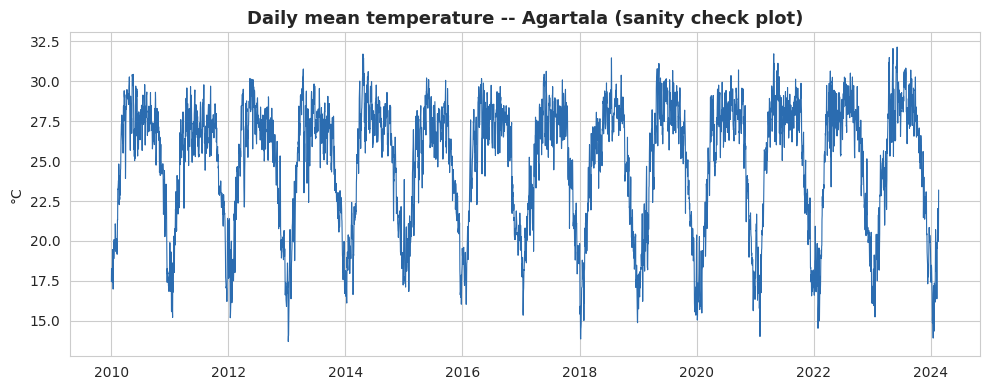

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sample_city = daily["city"].iloc[0]
sub = daily[daily["city"] == sample_city].sort_values("date")
ax.plot(sub["date"], sub["temp_mean"], color="#2b6cb0", linewidth=0.8)
ax.set_title(f"Daily mean temperature -- {sample_city} (sanity check plot)")
ax.set_ylabel("°C")
plt.tight_layout()
plt.show()

## 5. Save daily dataset

In [8]:
daily.to_parquet(PROCESSED_DIR / "daily_sample.parquet", index=False)
print("Saved:", PROCESSED_DIR / "daily_sample.parquet", daily.shape)

Saved: /kaggle/working/processed/daily_sample.parquet (206560, 24)
